In [10]:
# ============================================================
#  : DATA PREPROCESSING
# ============================================================

import joblib
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ------------------------------------------------------------
# Remove Data Leakage Columns
# ------------------------------------------------------------

leakage_columns = [
    "Delivery Status",
    "Days for shipping (real)",
    "Delivery Gap",
    "Delivery Performance"
]

for col in leakage_columns:
    if col in df.columns:
        df.drop(columns=col, inplace=True)

# ------------------------------------------------------------
# Separate Features and Target
# ------------------------------------------------------------

X = df.drop("Late_delivery_risk", axis=1)
y = df["Late_delivery_risk"]

print("Shape of X :", X.shape)
print("Shape of y :", y.shape)

# ------------------------------------------------------------
# Label Encoding
# ------------------------------------------------------------

label_encoders = {}

categorical_columns = X.select_dtypes(include=["object", "category"]).columns

for col in categorical_columns:

    encoder = LabelEncoder()

    X[col] = encoder.fit_transform(X[col].astype(str))

    label_encoders[col] = encoder

print("Encoding Completed")

# ------------------------------------------------------------
# Save Label Encoders
# ------------------------------------------------------------

joblib.dump(
    label_encoders,
    r"C:\Users\Dell\OneDrive\Desktop\APL_Late_Delivery_Prediction\Models\LabelEncoders.pkl"
)

print("Label Encoders Saved")

# ------------------------------------------------------------
# Save Feature Names
# ------------------------------------------------------------

model_features = X.columns.tolist()

joblib.dump(
    model_features,
    r"C:\Users\Dell\OneDrive\Desktop\APL_Late_Delivery_Prediction\Models\model_features.pkl"
)

print("Feature List Saved")

# ------------------------------------------------------------
# Train Test Split
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)

# ------------------------------------------------------------
# Feature Scaling
# ------------------------------------------------------------

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Scaling Completed")

# ------------------------------------------------------------
# Save Scaler
# ------------------------------------------------------------

joblib.dump(
    scaler,
    r"C:\Users\Dell\OneDrive\Desktop\APL_Late_Delivery_Prediction\Models\Scaler.pkl"
)

print("Scaler Saved Successfully")

# ------------------------------------------------------------
# Verify Saved Feature Order
# ------------------------------------------------------------

print("\nNumber of Features :", len(model_features))

print("\nFeature Names:\n")

for feature in model_features:
    print(feature)

Shape of X : (180519, 43)
Shape of y : (180519,)
Encoding Completed
Label Encoders Saved
Feature List Saved
Training Shape : (144415, 43)
Testing Shape  : (36104, 43)
Scaling Completed
Scaler Saved Successfully

Number of Features : 43

Feature Names:

Type
Days for shipment (scheduled)
Benefit per order
Sales per customer
Category Id
Category Name
Customer City
Customer Country
Customer Segment
Customer State
Customer Zipcode
Department Id
Department Name
Market
Order City
Order Country
Order Item Discount
Order Item Discount Rate
Order Item Product Price
Order Item Profit Ratio
Order Item Quantity
Sales
Order Item Total
Order Profit Per Order
Order Region
Order State
Order Status
Product Price
Shipping Mode
Shipping Pressure Index
Discount Percentage
Order Value Category
Profit Category
High Value Customer
Express Shipping
Large Order
Profit Margin
Sales Category
Customer Value Score
Shipping Efficiency
Order Complexity Score
Market Risk Score
Shipping Mode Risk


In [11]:
# ============================================================
# PART  : MODEL TRAINING
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score
import pandas as pd

# ------------------------------------------------------------
# Dictionary to Store Models
# ------------------------------------------------------------

models = {

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=150,
        learning_rate=0.1,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.10,
        max_depth=8,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss"
    )

}

# ------------------------------------------------------------
# Train Models
# ------------------------------------------------------------

trained_models = {}

accuracy_results = []

print("="*60)
print("TRAINING MODELS")
print("="*60)

for name, model in models.items():

    print(f"\nTraining {name}...")

    model.fit(X_train_scaled, y_train)

    prediction = model.predict(X_test_scaled)

    accuracy = accuracy_score(
        y_test,
        prediction
    )

    trained_models[name] = model

    accuracy_results.append({
        "Model": name,
        "Accuracy": accuracy
    })

    print(f"{name} Accuracy : {accuracy:.4f}")

print("\nTraining Completed Successfully.")

# ------------------------------------------------------------
# Accuracy Comparison Table
# ------------------------------------------------------------

accuracy_df = pd.DataFrame(accuracy_results)

accuracy_df = accuracy_df.sort_values(
    by="Accuracy",
    ascending=False
)

print("\nModel Comparison\n")

display(accuracy_df)

# ------------------------------------------------------------
# Select Best Model
# ------------------------------------------------------------

best_model_name = accuracy_df.iloc[0]["Model"]

best_model = trained_models[best_model_name]

print("\nBest Model :", best_model_name)

# ------------------------------------------------------------
# Force XGBoost as Final Model
# ------------------------------------------------------------

model = trained_models["XGBoost"]

print("\nFinal Deployment Model : XGBoost")

# ------------------------------------------------------------
# Predictions
# ------------------------------------------------------------

y_pred = model.predict(X_test_scaled)

y_prob = model.predict_proba(X_test_scaled)[:,1]

print("\nPrediction Completed.")

TRAINING MODELS

Training Logistic Regression...
Logistic Regression Accuracy : 0.9535

Training Random Forest...
Random Forest Accuracy : 0.9830

Training Gradient Boosting...
Gradient Boosting Accuracy : 0.9795

Training XGBoost...
XGBoost Accuracy : 0.9888

Training Completed Successfully.

Model Comparison



,Model,Accuracy
3,XGBoost,0.988838
1,Random Forest,0.982966
2,Gradient Boosting,0.979504
0,Logistic Regression,0.953523



Best Model : XGBoost

Final Deployment Model : XGBoost

Prediction Completed.


XGBOOST MODEL PERFORMANCE
Accuracy : 0.9888
Precision: 0.9911
Recall   : 0.9885
F1 Score : 0.9898
ROC AUC  : 0.9996

Classification Report

              precision    recall  f1-score   support

           0       0.99      0.99      0.99     16308
           1       0.99      0.99      0.99     19796

    accuracy                           0.99     36104
   macro avg       0.99      0.99      0.99     36104
weighted avg       0.99      0.99      0.99     36104



<Figure size 600x500 with 0 Axes>

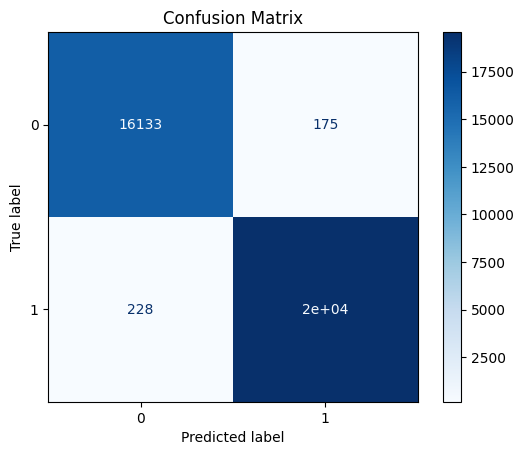

<Figure size 600x500 with 0 Axes>

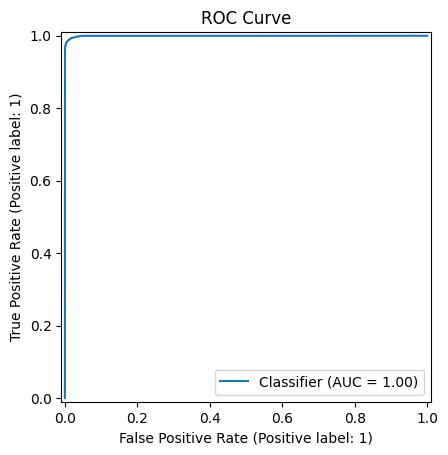


Top 15 Important Features



,Feature,Importance
39,Shipping Efficiency,0.478438
42,Shipping Mode Risk,0.351376
34,Express Shipping,0.095871
1,Days for shipment (scheduled),0.028238
28,Shipping Mode,0.017821
26,Order Status,0.010764
29,Shipping Pressure Index,0.005287
37,Sales Category,0.002912
21,Sales,0.001285
0,Type,0.001250


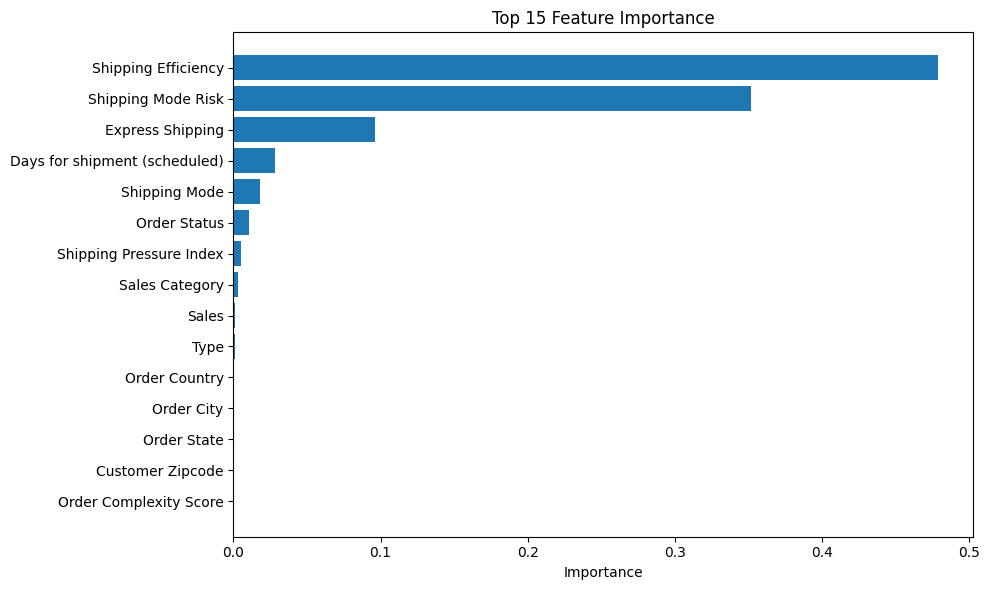

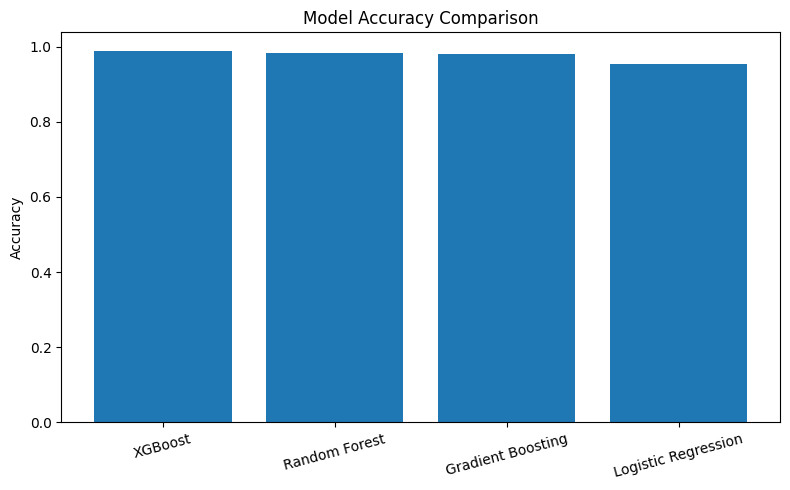


Model Saved Successfully

Files Required For Dashboard
Late_Delivery_Risk_Model.pkl
Scaler.pkl
LabelEncoders.pkl
model_features.pkl

Machine Learning Pipeline Completed Successfully


In [12]:
# ============================================================
# PART 5 : MODEL EVALUATION & MODEL SAVING
# ============================================================

import matplotlib.pyplot as plt
import joblib

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    RocCurveDisplay
)

# ------------------------------------------------------------
# MODEL PERFORMANCE
# ------------------------------------------------------------

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("=" * 60)
print("XGBOOST MODEL PERFORMANCE")
print("=" * 60)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC AUC  : {roc_auc:.4f}")

# ------------------------------------------------------------
# CLASSIFICATION REPORT
# ------------------------------------------------------------

print("\nClassification Report\n")

print(classification_report(y_test, y_pred))

# ------------------------------------------------------------
# CONFUSION MATRIX
# ------------------------------------------------------------

plt.figure(figsize=(6,5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.show()

# ------------------------------------------------------------
# ROC CURVE
# ------------------------------------------------------------

plt.figure(figsize=(6,5))

RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title("ROC Curve")
plt.show()

# ------------------------------------------------------------
# FEATURE IMPORTANCE
# ------------------------------------------------------------

importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": model.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nTop 15 Important Features\n")

display(importance.head(15))

plt.figure(figsize=(10,6))

plt.barh(
    importance.head(15)["Feature"][::-1],
    importance.head(15)["Importance"][::-1]
)

plt.title("Top 15 Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()

plt.show()

# ------------------------------------------------------------
# MODEL COMPARISON
# ------------------------------------------------------------

plt.figure(figsize=(8,5))

plt.bar(
    accuracy_df["Model"],
    accuracy_df["Accuracy"]
)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=15)

plt.tight_layout()

plt.show()

# ------------------------------------------------------------
# SAVE FINAL MODEL
# ------------------------------------------------------------

joblib.dump(
    model,
    r"C:\Users\Dell\OneDrive\Desktop\APL_Late_Delivery_Prediction\Models\Late_Delivery_Risk_Model.pkl"
)

print("\nModel Saved Successfully")

# ------------------------------------------------------------
# VERIFY ALL FILES
# ------------------------------------------------------------

print("\nFiles Required For Dashboard")

print("Late_Delivery_Risk_Model.pkl")
print("Scaler.pkl")
print("LabelEncoders.pkl")
print("model_features.pkl")

print("\nMachine Learning Pipeline Completed Successfully")

In [13]:
print(df.columns.tolist())

['Type', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Segment', 'Customer State', 'Customer Zipcode', 'Department Id', 'Department Name', 'Market', 'Order City', 'Order Country', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Product Price', 'Shipping Mode', 'Shipping Pressure Index', 'Discount Percentage', 'Order Value Category', 'Profit Category', 'High Value Customer', 'Express Shipping', 'Large Order', 'Profit Margin', 'Sales Category', 'Customer Value Score', 'Shipping Efficiency', 'Order Complexity Score', 'Market Risk Score', 'Shipping Mode Risk']
